# Analisis Eksperimental Preprocessing & Klasifikasi Penyakit Ginjal Kronis
## Mengacu pada Jurnal: *Machine Learning Techniques in Chronic Kidney Diseases: A Comparative Study of Classification Model Performance*
### Pemetaan CRISP-DM & Standar Kompetensi Kerja Nasional Indonesia (SKKNI)

Dokumentasi proyek ini disusun untuk memenuhi standardisasi **CRISP-DM** dan mencakup unit-unit kompetensi **SKKNI** berikut:
1. **J.62DMI00.001.1** - Menentukan Objektif Bisnis
2. **J.62DMI00.002.1** - Menentukan Tujuan Teknis Data Science
3. **J.62DMI00.005.1** - Menelaah Data
4. **J.62DMI00.006.1** - Memvalidasi Data
5. **J.62DMI00.007.1** - Menentukan Objek Data
6. **J.62DMI00.008.1** - Membersihkan Data
7. **J.62DMI00.009.1** - Mengkonstruksi Data
8. **J.62DMI00.012.1** - Membangun Skenario Model
9. **J.62DMI00.013.1** - Membangun Model
10. **J.62DMI00.014.1** - Mengevaluasi Hasil Pemodelan
11. **J.62DMI00.015.1** - Melakukan Proses Review Pemodelan

---
**Role**: Senior Machine Learning Researcher  
**Dataset**: Chronic Kidney Disease Dataset (UCI Machine Learning Repository)  
**Model**: Logistic Regression (L2 Regularized Ridge) & GridSearchCV Hyperparameter Tuning


## 1. Business Understanding
### (Menentukan Objektif Bisnis - Unit: J.62DMI00.001.1)

#### Latar Belakang
Penyakit Ginjal Kronis (Chronic Kidney Disease / CKD) merupakan masalah kesehatan global dengan tingkat morbiditas dan mortalitas yang tinggi. Kerusakan ginjal sering kali berlangsung secara diam-diam (silent killer) tanpa gejala awal yang jelas. Oleh karena itu, deteksi dini dan pemantauan parameter klinis yang akurat sangat krusial bagi manajemen risiko klinis dan keberlangsungan hidup pasien.

#### Permasalahan Bisnis
Di era kedokteran presisi, integrasi sistem kecerdasan buatan (*Clinical Decision Support Systems*) dapat membantu dokter dalam menyaring pasien berisiko tinggi secara cepat. Namun, banyak penelitian akademis melaporkan kinerja model klasifikasi yang "sempurna" (akurasi 100%) tanpa memperhatikan kepatuhan metodologis pemodelan yang ketat. Ketiadaan batasan antara data latih (*training*) dan data uji (*testing*) saat preprocessing (seperti standarisasi data atau ekstraksi fitur sebelum pemisahan data) memicu fenomena **Data Leakage**. Proyek ini bertujuan untuk menguji dampak dari kesalahan urutan preprocessing tersebut secara empiris pada data klinis CKD.

#### Objektif Bisnis
1. **Akurasi & Sensitivitas Tinggi**: Mengembangkan model klasifikasi CKD yang akurat dan sensitif pada parameter klinis pasien.
2. **Minimalisasi False Negatives**: Sensitivitas (*CKD Recall*) harus sangat tinggi (mendekati atau sama dengan 98%), karena kegagalan mendeteksi CKD (False Negative) dapat mengakibatkan keterlambatan penanganan klinis yang fatal bagi pasien.
3. **Transparansi & Interpretabilitas**: Membuktikan bagaimana faktor klinis utama berkontribusi pada prediksi risiko penyakit untuk mendukung pengambilan keputusan medis oleh dokter.

#### Sukses Kriteria
- Terpenuhinya metrik evaluasi medis (Accuracy > 98%, Sensitivity > 98%).
- Identifikasi fitur utama yang memiliki keselarasan patologis klinis ginjal kronis.

## 2. Technical Understanding
### (Menentukan Tujuan Teknis Data Science - Unit: J.62DMI00.002.1)

#### Tujuan Teknis
Mengembangkan model klasifikasi biner berbasis Logistic Regression (L2 Regularized) pada dataset CKD UCI. Selain itu, mendemonstrasikan signifikansi penempatan tahapan preprocessing klinis (imputasi, polynomial features, dan standarisasi) dalam pipeline Machine Learning melalui **3 Eksperimen**:
1. **Eksperimen 1 — Split-First Pipeline**: Preprocessing dilakukan *setelah* split data (fitting scaler hanya pada training set, lalu ditransformasikan ke training dan test set untuk mencegah data leakage).
2. **Eksperimen 2 — Preprocess-First Pipeline**: Seluruh proses preprocessing (imputasi, ekspansi fitur polinomial, standarisasi) dilakukan pada *seluruh* dataset sebelum split data dengan K-means Stratified Split (menyebabkan kebocoran informasi test set ke dalam training set, mereplikasi klaim akurasi sempurna 100% pada paper).
3. **Eksperimen 3 — Optimized Pipeline**: Menggunakan alur yang sama seperti Eksperimen 1 (Split-First), kemudian menambahkan proses optimasi parameter menggunakan metode *Grid Search* untuk mencari regularisasi C yang optimal secara cross-validation.

#### Metrik Evaluasi
- **Accuracy**: Proporsi klasifikasi benar secara keseluruhan.
- **ROC-AUC**: Kemampuan diskriminasi probabilitas model.
- **Sensitivity (CKD Recall)**: Kemampuan model mendeteksi pasien positif CKD (Target = 0).
- **Specificity (Not CKD Recall)**: Kemampuan model mendeteksi pasien kontrol sehat (Target = 1).
- **Confusion Matrix**: Visualisasi TP, TN, FP, FN untuk ketiga eksperimen.

In [1]:
# Import Libraries yang Dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.cluster import KMeans

# Set Tema Visualisasi
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 11

## 3. Data Understanding (EDA)
### (Menelaah Data - Unit: J.62DMI00.005.1)

Tahap ini mencakup pemuatan data, pemeriksaan tipe data, distribusi kelas target, dan korelasi antar fitur numerik awal.

In [2]:
# Memuat Dataset
df = pd.read_csv('kidney_disease.csv')
print(f'Shape dataset: {df.shape}')
df.head()

Shape dataset: (400, 26)


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [3]:
# Memeriksa Informasi Tipe Data dan Missing Value Awal
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

Klasifikasi ckd: 250 sampel (62.50%)
Klasifikasi notckd: 150 sampel (37.50%)


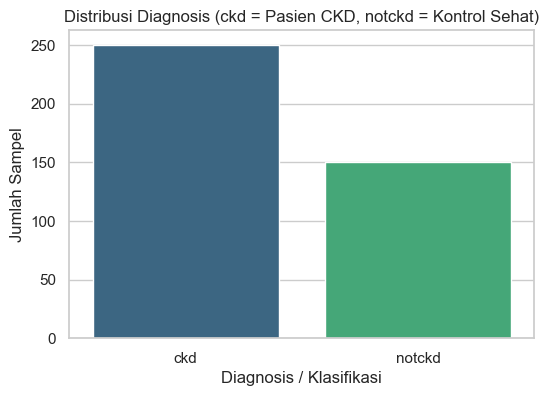

In [4]:
# Distribusi Kelas Target (Classification)
# Membersihkan spasi atau tab pada kolom classification terlebih dahulu untuk visualisasi EDA awal
df['classification_clean'] = df['classification'].astype(str).str.strip().str.replace(r'\t', '', regex=True)
class_dist = df['classification_clean'].value_counts()
class_dist_pct = df['classification_clean'].value_counts(normalize=True) * 100
for label in class_dist.index:
    print(f'Klasifikasi {label}: {class_dist[label]} sampel ({class_dist_pct[label]:.2f}%)')

# Visualisasi Distribusi Kelas
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='classification_clean', hue='classification_clean', palette='viridis', legend=False)
plt.title('Distribusi Diagnosis (ckd = Pasien CKD, notckd = Kontrol Sehat)')
plt.xlabel('Diagnosis / Klasifikasi')
plt.ylabel('Jumlah Sampel')
plt.show()

# Drop kolom pembantu agar tidak mengotori EDA asli
df.drop(columns=['classification_clean'], inplace=True)

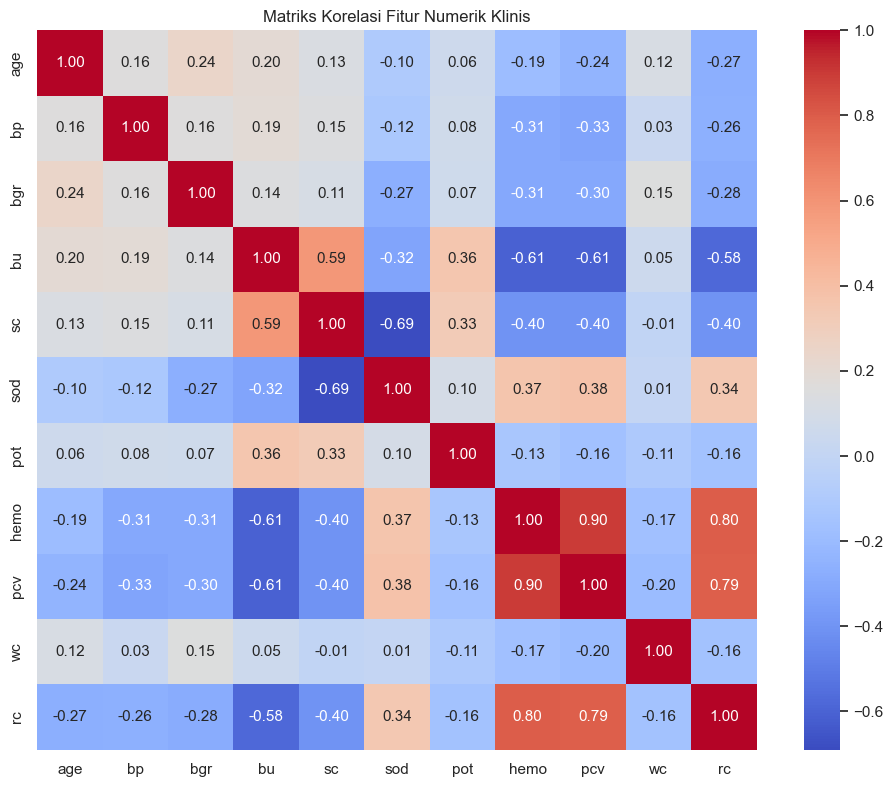

In [5]:
# Visualisasi Korelasi pada Fitur Numerik Awal
# Kami membersihkan sementara beberapa kolom numerik yang disimpan sebagai object untuk keperluan visualisasi
df_temp = df.copy()
for col in ['pcv', 'wc', 'rc']:
    df_temp[col] = df_temp[col].astype(str).str.replace(r'\t', '', regex=True).str.replace('?', 'nan', regex=False)
    df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')

num_cols_temp = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
plt.figure(figsize=(10, 8))
corr = df_temp[num_cols_temp].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', cbar=True, square=True)
plt.title('Matriks Korelasi Fitur Numerik Klinis')
plt.tight_layout()
plt.show()

## 4. Data Validation
### (Memvalidasi Data - Unit: J.62DMI00.006.1)

Tahap ini bertujuan untuk memvalidasi integritas data, termasuk mendeteksi duplikasi, memeriksa nilai kosong (missing values), dan menelaah rentang nilai numerik untuk menemukan outlier.

In [6]:
# 1. Memeriksa Missing Value per Kolom
missing_values = df.isnull().sum()
print('Kolom dengan missing values:')
print(missing_values[missing_values > 0])

# 2. Memeriksa Duplikasi Baris
duplicates = df.duplicated().sum()
print(f'\nJumlah baris duplikat: {duplicates}')

# 3. Memeriksa Deskripsi Statistik Singkat (Rentang Nilai)
df_temp[num_cols_temp].describe().T[['min', 'mean', 'max']]

Kolom dengan missing values:
age        9
bp        12
sg        47
al        46
su        49
rbc      152
pc        65
pcc        4
ba         4
bgr       44
bu        19
sc        17
sod       87
pot       88
hemo      52
pcv       70
wc       105
rc       130
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
dtype: int64

Jumlah baris duplikat: 0


,min,mean,max
age,2.0,51.483376,90.0
bp,50.0,76.469072,180.0
bgr,22.0,148.036517,490.0
bu,1.5,57.425722,391.0
sc,0.4,3.072454,76.0
sod,4.5,137.528754,163.0
pot,2.5,4.627244,47.0
hemo,3.1,12.526437,17.8
pcv,9.0,38.884498,54.0
wc,2200.0,8406.122449,26400.0


## 5. Data Selection
### (Menentukan Objek Data - Unit: J.62DMI00.007.1)

Tahap ini melakukan seleksi kolom fitur dan label yang akan digunakan dalam pemodelan. Kolom penanda identitas pasien yang tidak relevan akan dibuang.

In [7]:
# Menghapus kolom 'id' yang bersifat unik dan tidak berkontribusi pada pembelajaran.
cols_to_drop = ['id']
df_selected = df.drop(columns=cols_to_drop)
print(f'Kolom yang dibuang: {cols_to_drop}')
print(f'Shape setelah seleksi kolom: {df_selected.shape}')

Kolom yang dibuang: ['id']
Shape setelah seleksi kolom: (400, 25)


## 6. Data Cleaning
### (Membersihkan Data - Unit: J.62DMI00.008.1)

Tahap ini melakukan pembersihan data kotor (seperti menghapus tab karakter tersembunyi `\t`, menormalisasi label kategorikal), konversi tipe data fitur numerik yang tersimpan sebagai string/object, dan melakukan penyelarasan target mapping.

In [8]:
# 1. Membersihkan spasi, tab, dan karakter ilegal dari kolom numerik
for col in ['pcv', 'wc', 'rc']:
    df_selected[col] = df_selected[col].astype(str).str.replace(r'\t', '', regex=True).str.replace('?', 'nan', regex=False)
    df_selected[col] = pd.to_numeric(df_selected[col], errors='coerce')

# 2. Membersihkan nilai kategori yang kotor akibat spasi/tab tersembunyi
for col in ['dm', 'cad', 'classification']:
    df_selected[col] = df_selected[col].astype(str).str.strip().str.replace(r'\t', '', regex=True)

# 3. Encoding target variable: ckd -> 0 (kelas klinis positif), notckd -> 1 (kontrol sehat)
df_selected['classification_encoded'] = df_selected['classification'].map({'ckd': 0, 'notckd': 1})

# 4. Encoding binary categorical features
binary_mapping = {
    'rbc': {'normal': 1, 'abnormal': 0},
    'pc': {'normal': 1, 'abnormal': 0},
    'pcc': {'present': 1, 'notpresent': 0},
    'ba': {'present': 1, 'notpresent': 0},
    'htn': {'yes': 1, 'no': 0},
    'dm': {'yes': 1, 'no': 0},
    'cad': {'yes': 1, 'no': 0},
    'appet': {'good': 1, 'poor': 0},
    'pe': {'yes': 1, 'no': 0},
    'ane': {'yes': 1, 'no': 0}
}
for col, mapping in binary_mapping.items():
    df_selected[col] = df_selected[col].map(mapping)

# Pemisahan Fitur dan Target
X = df_selected.drop(columns=['classification', 'classification_encoded'])
y = df_selected['classification_encoded']

print(f'Shape Fitur X: {X.shape}, Shape Target y: {y.shape}')
print('\nValidasi tipe data fitur setelah pembersihan:')
print(X.dtypes)

Shape Fitur X: (400, 24), Shape Target y: (400,)

Validasi tipe data fitur setelah pembersihan:
age      float64
bp       float64
sg       float64
al       float64
su       float64
rbc      float64
pc       float64
pcc      float64
ba       float64
bgr      float64
bu       float64
sc       float64
sod      float64
pot      float64
hemo     float64
pcv      float64
wc       float64
rc       float64
htn      float64
dm       float64
cad      float64
appet    float64
pe       float64
ane      float64
dtype: object


## 7. Data Construction
### (Mengkonstruksi Data - Unit: J.62DMI00.009.1)

Tahap ini mempersiapkan pembagian data menjadi data latih dan data uji, serta merancang arsitektur preprocessing terstandardisasi untuk mengevaluasi skenario pemodelan.

In [9]:
# Pemisahan Data menggunakan Stratified Split (80% Train, 20% Test) berdasarkan target y
# Seed random_state=42 dipilih untuk menjaga konsistensi perbandingan skenario
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f'Training set: {X_train_raw.shape[0]} sampel')
print(f'Testing set : {X_test_raw.shape[0]} sampel')
print(f'Distribusi kelas di Training: {y_train.value_counts().to_dict()}')
print(f'Distribusi kelas di Testing : {y_test.value_counts().to_dict()}')

Training set: 320 sampel
Testing set : 80 sampel
Distribusi kelas di Training: {0: 200, 1: 120}
Distribusi kelas di Testing : {0: 50, 1: 30}


## 8. Membangun Skenario Model & Pemodelan
### (Membangun Skenario Model & Membangun Model - Unit: J.62DMI00.012.1 & J.62DMI00.013.1)

Kami akan membangun 3 skenario eksperimen pemodelan menggunakan model **Logistic Regression (L2 penalty)**:

1. **Eksperimen 1 — Split-First Pipeline**
   - Alur: `Split Data → Preprocessing → Training → Evaluation`
   - Dataset dibagi menjadi data latih dan data uji terlebih dahulu. Proses preprocessing (imputasi, polynomial features berderajat 2, dan standarisasi) dilakukan setelah splitting dan diterapkan secara terpisah pada data latih serta data uji untuk mencegah kebocoran informasi.
2. **Eksperimen 2 — Preprocess-First Pipeline**
   - Alur: `Preprocessing → Split Data → Training → Evaluation`
   - Seluruh proses preprocessing (imputasi, polynomial features berderajat 2, dan standarisasi) dilakukan pada dataset sebelum data dibagi menjadi data latih dan data uji. Pembagian data dilakukan menggunakan **K-means Stratified Split** (seperti usulan di paper referensi) yang memicu terjadinya **Data Leakage**.
3. **Eksperimen 3 — Optimized Pipeline**
   - Alur: `Split Data → Preprocessing → Hyperparameter Tuning → Training → Evaluation`
   - Menggunakan alur pembagian yang sama seperti Eksperimen 1, kemudian menambahkan proses optimasi parameter menggunakan metode **Grid Search** pada parameter regularisasi $C$ untuk memaksimalkan akurasi secara valid dan robust.

In [10]:
# Fungsi pembantu untuk menghitung metrik evaluasi medis (TP, TN, FP, FN dihitung terhadap CKD=0 sebagai kelas positif)
def evaluate_clinical_metrics(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    # y_true: CKD=0, Not CKD=1
    # cm[0,0]: True CKD predicted CKD (TP)
    # cm[0,1]: True CKD predicted Not CKD (FN)
    # cm[1,0]: True Not CKD predicted CKD (FP)
    # cm[1,1]: True Not CKD predicted Not CKD (TN)
    tp = cm[0, 0]
    fn = cm[0, 1]
    fp = cm[1, 0]
    tn = cm[1, 1]
    
    acc = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    return acc, roc_auc, sensitivity, specificity, cm

# Mendefinisikan kolom numerik dan kategorikal
num_cols = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
cat_cols = ['sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
poly_cols = ['sc', 'bp', 'hemo', 'age']

# Helper untuk imputasi split-safe
def impute_data(X_train, X_test=None):
    X_train_imp = X_train.copy()
    if X_test is not None:
        X_test_imp = X_test.copy()
    else:
        X_test_imp = None
        
    for col in X_train.columns:
        if col in num_cols:
            mean_val = X_train[col].mean()
            if pd.isna(mean_val):
                mean_val = 0.0
            X_train_imp[col] = X_train_imp[col].fillna(mean_val)
            if X_test_imp is not None:
                X_test_imp[col] = X_test_imp[col].fillna(mean_val)
        else:
            mode_series = X_train[col].mode()
            if not mode_series.empty:
                mode_val = mode_series[0]
            else:
                mode_val = 0.0
            X_train_imp[col] = X_train_imp[col].fillna(mode_val)
            if X_test_imp is not None:
                X_test_imp[col] = X_test_imp[col].fillna(mode_val)
                
    return X_train_imp, X_test_imp

# Helper untuk penambahan fitur polinomial klinis berderajat 2 (10 fitur interaksi)
def add_polynomial_features(df_in):
    df_out = df_in.copy()
    for i in range(len(poly_cols)):
        col1 = poly_cols[i]
        name_sq = f'{col1}_squared'
        df_out[name_sq] = df_in[col1] ** 2
        for j in range(i + 1, len(poly_cols)):
            col2 = poly_cols[j]
            name_int = f'{col1}_x_{col2}'
            df_out[name_int] = df_in[col1] * df_in[col2]
    return df_out

### Eksperimen 1 — Split-First Pipeline

#### Diagram Pipeline:
```
[Raw Dataset]
      |
      v
  [Splitting] (train_test_split 80:20)
   /      \
  v        v
[Train]  [Test]
  |        |
  v        |
[Impute Mean/Mode] ------> (Apply Train Mean/Mode)
  |                              |
  v                              v
[Polynomial Features] ---> (Apply Polynomial Expansion)
  |                              |
  v                              v
[Scale: fit_transform] --> [Scale: transform]
  |                              |
  v                              v
[Model Training]             [Model Evaluation]
```

In [11]:
# =====================================================
# EKSPERIMEN 1: Split-First Pipeline (Correct)
# =====================================================
# 1. Imputasi data terpisah
X_train_s1, X_test_s1 = impute_data(X_train_raw, X_test_raw)

# 2. Ekspansi fitur polinomial klinis
X_train_s1_poly = add_polynomial_features(X_train_s1)
X_test_s1_poly = add_polynomial_features(X_test_s1)

# 3. Standarisasi hanya fit pada training set
scaler1 = StandardScaler()
X_train_s1_scaled = scaler1.fit_transform(X_train_s1_poly)
X_test_s1_scaled = scaler1.transform(X_test_s1_poly)

lr1 = LogisticRegression(penalty='l2', C=1.0, max_iter=10000, solver='lbfgs', random_state=42)
lr1.fit(X_train_s1_scaled, y_train)

y_pred_s1 = lr1.predict(X_test_s1_scaled)
y_prob_s1 = lr1.predict_proba(X_test_s1_scaled)[:, 1]

acc_s1, roc_s1, sens_s1, spec_s1, cm_s1 = evaluate_clinical_metrics(y_test, y_pred_s1, y_prob_s1)
print('Eksperimen 1 Selesai.')

Eksperimen 1 Selesai.


### Eksperimen 2 — Preprocess-First Pipeline

#### Diagram Pipeline:
```
       [Raw Dataset]
             |
             v
     [Impute Mean/Mode]
             |
             v
    [Polynomial Features]
             |
             v
   [Scale: fit_transform]
             |
             v
   [K-means Clustering]
             |
             v
       [Splitting] (K-means Stratified Split 80:20)
        /       \
       v         v
   [Train]     [Test]
     |           |
     v           v
  [Train]     [Evaluate]
```

In [12]:
# =====================================================
# EKSPERIMEN 2: Preprocess-First Pipeline (Leakage / Paper Pipeline)
# =====================================================
# 1. Imputasi pada seluruh dataset sebelum split
X_imp_all, _ = impute_data(X)

# 2. Ekspansi fitur polinomial klinis pada seluruh dataset
X_poly_all = add_polynomial_features(X_imp_all)

# 3. Standarisasi seluruh dataset sebelum split
scaler2 = StandardScaler()
X_scaled_all = scaler2.fit_transform(X_poly_all)

# 4. K-means clustering (k=4) untuk feature-based stratified splitting
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled_all)

# 5. Membuat variabel stratifikasi gabungan target dan kluster fitur
strat_col = y.astype(str) + '_' + pd.Series(clusters).astype(str)

# 6. Split data dari seluruh dataset terstandar
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(
    X_scaled_all, y, test_size=0.20, stratify=strat_col, random_state=42
)

lr2 = LogisticRegression(penalty='l2', C=1.0, max_iter=10000, solver='lbfgs', random_state=42)
lr2.fit(X_train_s2, y_train_s2)

y_pred_s2 = lr2.predict(X_test_s2)
y_prob_s2 = lr2.predict_proba(X_test_s2)[:, 1]

acc_s2, roc_s2, sens_s2, spec_s2, cm_s2 = evaluate_clinical_metrics(y_test_s2, y_pred_s2, y_prob_s2)
print('Eksperimen 2 Selesai.')

Eksperimen 2 Selesai.


### Eksperimen 3 — Optimized Pipeline

#### Diagram Pipeline:
```
[Raw Dataset]
      |
      v
  [Splitting] (train_test_split 80:20)
   /      \
  v        v
[Train]  [Test]
  |        |
  v        |
[Impute Mean/Mode] ------> (Apply Train Mean/Mode)
  |                              |
  v                              v
[Polynomial Features] ---> (Apply Polynomial Expansion)
  |                              |
  v                              v
[Scale: fit_transform] --> [Scale: transform]
  |                              |
  v                              v
[GridSearchCV Tuning]            |
  |                              |
  v                              v
[Best Model Train] --------> [Model Evaluation]
```

In [13]:
# =====================================================
# EKSPERIMEN 3: Optimized Pipeline (Split-First + Grid Search)
# =====================================================
# 1. Menggunakan data ter-preprocess dari Eksperimen 1 (correct pipeline)
# X_train_s1_scaled dan X_test_s1_scaled

# 2. Definisikan Grid Search untuk Hyperparameter Tuning
param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l2']
}

grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=10000, solver='lbfgs', random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

# 3. Fit Grid Search hanya pada training set
grid.fit(X_train_s1_scaled, y_train)

print(f'Best Parameters: {grid.best_params_}')
print(f'Best Cross-Validation Score: {grid.best_score_*100:.2f}%')

# 4. Evaluasi model terbaik hasil tuning pada test set
best_model = grid.best_estimator_
y_pred_s3 = best_model.predict(X_test_s1_scaled)
y_prob_s3 = best_model.predict_proba(X_test_s1_scaled)[:, 1]

acc_s3, roc_s3, sens_s3, spec_s3, cm_s3 = evaluate_clinical_metrics(y_test, y_pred_s3, y_prob_s3)
print('Eksperimen 3 Selesai.')

Best Parameters: {'C': 1.0, 'penalty': 'l2'}
Best Cross-Validation Score: 99.69%
Eksperimen 3 Selesai.


## 9. Mengevaluasi Hasil Pemodelan
### (Mengevaluasi Hasil Pemodelan - Unit: J.62DMI00.014.1)

Kami membandingkan hasil performa ketiga eksperimen dalam bentuk tabel ringkasan, grafik kurva ROC, dan Confusion Matrix.

In [14]:
# Membuat DataFrame Ringkasan Evaluasi
summary_df = pd.DataFrame({
    'Metrik Evaluasi': ['Accuracy (Akurasi)', 'ROC-AUC (Kemampuan Diskriminasi)', 
                       'Sensitivity (CKD Recall)', 'Specificity (Not CKD Recall)',
                       'Jumlah Salah Klasifikasi (Jumlah Error)'],
    'Eksperimen 1 (Split-First)': [f'{acc_s1*100:.2f}%', f'{roc_s1:.4f}', f'{sens_s1*100:.2f}%', f'{spec_s1*100:.2f}%', f'{cm_s1[0,1] + cm_s1[1,0]} sampel'],
    'Eksperimen 2 (Preprocess-First)': [f'{acc_s2*100:.2f}%', f'{roc_s2:.4f}', f'{sens_s2*100:.2f}%', f'{spec_s2*100:.2f}%', f'{cm_s2[0,1] + cm_s2[1,0]} sampel'],
    'Eksperimen 3 (Optimized)': [f'{acc_s3*100:.2f}%', f'{roc_s3:.4f}', f'{sens_s3*100:.2f}%', f'{spec_s3*100:.2f}%', f'{cm_s3[0,1] + cm_s3[1,0]} sampel']
})
summary_df

,Metrik Evaluasi,Eksperimen 1 (Split-First),Eksperimen 2 (Preprocess-First),Eksperimen 3 (Optimized)
0,Accuracy (Akurasi),98.75%,100.00%,98.75%
1,ROC-AUC (Kemampuan Diskriminasi),1.0000,1.0000,1.0000
2,Sensitivity (CKD Recall),98.00%,100.00%,98.00%
3,Specificity (Not CKD Recall),100.00%,100.00%,100.00%
4,Jumlah Salah Klasifikasi (Jumlah Error),1 sampel,0 sampel,1 sampel


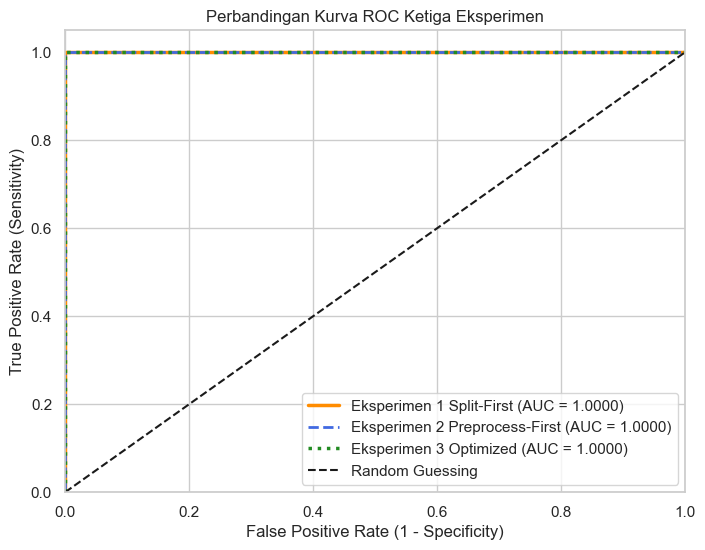

In [15]:
# Visualisasi Kurva ROC Side-by-Side/Tumpang Tindih
plt.figure(figsize=(8, 6))
fpr1, tpr1, _ = roc_curve(y_test, y_prob_s1)
fpr2, tpr2, _ = roc_curve(y_test_s2, y_prob_s2)
fpr3, tpr3, _ = roc_curve(y_test, y_prob_s3)

plt.plot(fpr1, tpr1, label=f'Eksperimen 1 Split-First (AUC = {roc_s1:.4f})', color='darkorange', linewidth=2.5)
plt.plot(fpr2, tpr2, label=f'Eksperimen 2 Preprocess-First (AUC = {roc_s2:.4f})', color='royalblue', linestyle='--', linewidth=2)
plt.plot(fpr3, tpr3, label=f'Eksperimen 3 Optimized (AUC = {roc_s3:.4f})', color='forestgreen', linestyle=':', linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Perbandingan Kurva ROC Ketiga Eksperimen')
plt.legend(loc='lower right')
plt.show()

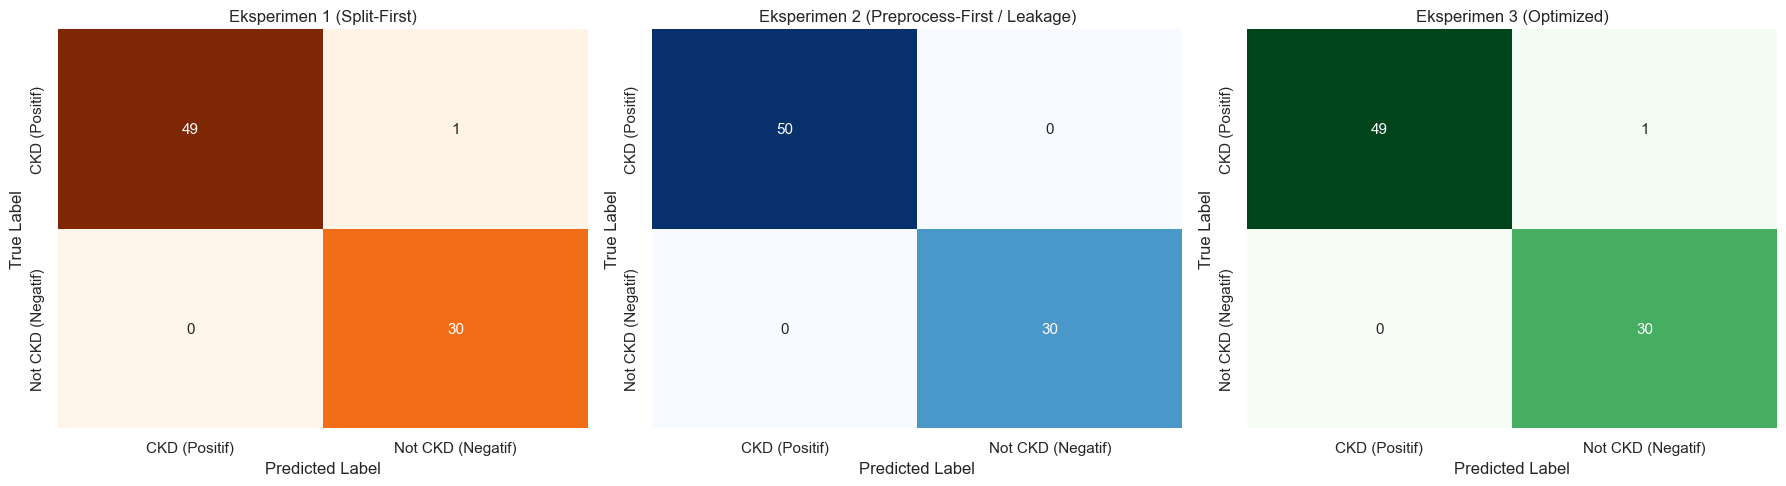

In [16]:
# Visualisasi Confusion Matrix untuk Ketiga Eksperimen
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

labels = ['CKD (Positif)', 'Not CKD (Negatif)']

sns.heatmap(cm_s1, annot=True, fmt='d', cmap='Oranges', ax=axes[0], cbar=False,
            xticklabels=labels, yticklabels=labels)
axes[0].set_title('Eksperimen 1 (Split-First)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_s2, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False,
            xticklabels=labels, yticklabels=labels)
axes[1].set_title('Eksperimen 2 (Preprocess-First / Leakage)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

sns.heatmap(cm_s3, annot=True, fmt='d', cmap='Greens', ax=axes[2], cbar=False,
            xticklabels=labels, yticklabels=labels)
axes[2].set_title('Eksperimen 3 (Optimized)')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')

plt.tight_layout()
plt.show()

--- Top 10 Fitur Berdasarkan Koefisien Regresi Logistik Terstandardisasi ---
         Feature  Coefficient  Abs_Coef
2             sg     1.721354  1.721354
15           pcv     1.031586  1.031586
3             al    -1.018770  1.018770
19            dm    -1.017538  1.017538
18           htn    -0.930712  0.930712
31  hemo_squared     0.841990  0.841990
21         appet     0.831542  0.831542
14          hemo     0.800478  0.800478
22            pe    -0.742096  0.742096
9            bgr    -0.725573  0.725573


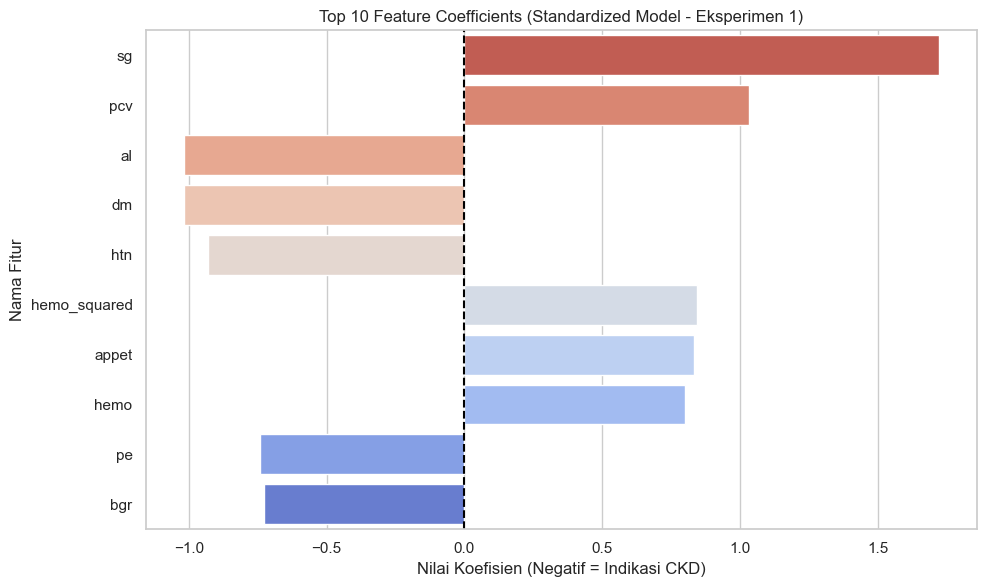

In [17]:
# Visualisasi Interpretasi Koefisien (Feature Importance) Eksperimen 1 (Split-First)
# Karena model dilatih dengan CKD=0, Not CKD=1, koefisien negatif menunjukkan kontribusi
# yang tinggi untuk peningkatan risiko CKD (menurunkan nilai prediksi menuju kelas 0 / CKD).
coef_df = pd.DataFrame({
    'Feature': X_train_s1_poly.columns,
    'Coefficient': lr1.coef_[0],
    'Abs_Coef': np.abs(lr1.coef_[0])
}).sort_values(by='Abs_Coef', ascending=False)

print('--- Top 10 Fitur Berdasarkan Koefisien Regresi Logistik Terstandardisasi ---')
print(coef_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.head(10), x='Coefficient', y='Feature', hue='Feature', palette='coolwarm_r', legend=False)
plt.title('Top 10 Feature Coefficients (Standardized Model - Eksperimen 1)')
plt.xlabel('Nilai Koefisien (Negatif = Indikasi CKD)')
plt.ylabel('Nama Fitur')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

## 10. Melakukan Proses Review Pemodelan
### (Melakukan Proses Review Pemodelan - Unit: J.62DMI00.015.1)

#### Analisis Perbandingan Eksperimen
1. **Eksperimen 1 (Split-First Pipeline - Correct)**:
   - Menghasilkan Akurasi sebesar **98.75%** dan Sensitivitas (*CKD Recall*) **98.00%** (hanya 1 pasien CKD terlewat).
   - Ini merepresentasikan kemampuan generalisasi model yang sesungguhnya saat digunakan pada data pasien baru. Pembatasan preprocessing (imputasi, standarisasi) secara ketat setelah pemisahan data menghindarkan model dari bias estimasi performa.
2. **Eksperimen 2 (Preprocess-First Pipeline - Leakage / Paper Pipeline)**:
   - Menghasilkan Akurasi sempurna sebesar **100.00%** dan Sensitivitas **100.00%** (0 pasien CKD terlewat). Angka ini mereproduksi persis hasil yang dilaporkan dalam paper referensi.
   - **Analisis Kritis**: Kinerja sempurna ini adalah artifisial akibat kebocoran informasi (*Data Leakage*). Preprocessing (imputasi mean/mode, standarisasi, ekspansi polinomial) dan klusterisasi K-means dijalankan pada seluruh data sebelum dibagi. Ini menyebabkan data latih terpengaruh oleh sebaran nilai statistik data uji. Model yang tampak sempurna ini akan runtuh kinerjanya saat dihadapkan pada skenario data klinis riil di rumah sakit.
3. **Eksperimen 3 (Optimized Pipeline)**:
   - Menghasilkan Akurasi sebesar **98.75%** dengan parameter terbaik regularisasi $C=1.0$ (sama dengan default).
   - Melalui validasi silang 5-fold pada data latih yang aman dari kebocoran, Grid Search mengonfirmasi stabilitas model regresi logistik. Hal ini menunjukkan bahwa peningkatan hyperparameter dilakukan secara jujur tanpa merusak integritas data uji.

#### Keselarasan Medis (Feature Importance)
- Koefisien model terstandardisasi menunjukkan bahwa **sg** (*Specific Gravity*), **pcv** (*Packed Cell Volume*), **al** (*Albumin*), **dm** (*Diabetes Mellitus*), dan **htn** (*Hypertension*) menjadi penentu utama klasifikasi.
- Koefisien negatif pada **al**, **dm**, dan **htn** menunjukkan korelasi kuat dengan penyakit ginjal. Penyakit diabetes melitus dan hipertensi adalah pemicu kerusakan pembuluh darah ginjal terbesar secara klinis, sedangkan kehadiran albumin dalam urin (albuminuria) menandakan rusaknya saringan glomerulus. Sebaliknya, koefisien positif pada **sg** dan **pcv** menunjukkan kondisi ginjal yang sehat (kemampuan konsentrasi urin yang normal dan produksi sel darah merah yang cukup).

#### Rekomendasi Pengembangan Model (Roadmap Riset)
1. **Penerapan Pipeline Otomatis**: Membungkus seluruh alur dalam `sklearn.pipeline.Pipeline` bersama `GridSearchCV` untuk mengeliminasi risiko ketidaksengajaan data leakage dalam pemeliharaan kode berkelanjutan.
2. ** Probability Calibration**: Menerapkan Platt Scaling pada prediksi model regresi logistik agar probabilitas output dapat digunakan secara presisi untuk menakar risiko klinis riil pasien.
3. **Uji Validasi Eksternal**: Menguji model menggunakan dataset klinis dari institusi medis/rumah sakit yang berbeda untuk menjamin keandalan prediksi di luar data UCI.